# Erste explorative Analyse: Preis, Regelzonenbilanz, Wetter und Feiertage 2026

**Frage:** Wie sehen die Daten aus, und welche Zusammenhänge könnten für eine Prognose um **11:00 am Vortag (D−1)** nutzbar sein?

Grundlage ist [Issue #3](https://github.com/ibidreli/energy_price_prediction/issues/3), Hypothesen H1 bis H7, dazu H8 aus dem Review. Ablauf nach dem Skill `exploratory-data-analysis`: zuerst der automatische Bericht (Schritt 0), dann Typen, Fehlwerte, Duplikate, Verteilungen, Ausreisser, Zusammenhänge und Zeitmuster, danach die Hypothesen.

**Leak-Regel für dieses Notebook:** Zusammenhänge *derselben* Viertelstunde (z.B. TSI und Preis) werden nur gezeigt, um den Mechanismus zu verstehen. Als Merkmal sind sie verboten. Für jede Merkmalsidee steht dabei, ob sie um 11:00 an D−1 bekannt ist (Swissgrid nur bis Ende D−2, Grenze noch eine **Annahme** bis ca. 18.10.2026; Wetter aus dem Lauf D−2 18 UTC; Feiertage ohne Einschränkung). Siehe [`docs/data.md`](../docs/data.md#1-die-regel-gegen-datenlecks).

Die Zusammenfassung mit Merkmals-Kandidaten steht in [`docs/eda.md`](../docs/eda.md).

## Setup

In [1]:
import os
import random
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The notebook runs from notebooks/; all paths are relative to the project root.
if Path.cwd().name == "notebooks":
    os.chdir("..")

from energy_price import eda
from energy_price.figures_data import BLUE, CATEGORICAL, INK, INK_2, MUTED, SURFACE, style

# figures_data switches matplotlib to Agg for `make figures`; back to inline so the figures show here.
%matplotlib inline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

style()
FIGURES = Path("docs/figures")
RED = "#e34948"  # red pole of the diverging pair of the reference palette (blue <-> gray <-> red)
DIVERGING = matplotlib.colors.LinearSegmentedColormap.from_list("div", [BLUE, "#f0efec", RED])
TZ = "Europe/Zurich"

print(f"python {sys.version.split()[0]} ({os.path.relpath(sys.executable)})")  # relative: no local home path in the repo
print(f"pandas {pd.__version__}, numpy {np.__version__}, matplotlib {matplotlib.__version__}")

python 3.14.7 (.venv/bin/python)
pandas 3.0.6, numpy 2.5.3, matplotlib 3.11.2


Der Kernel muss in `.venv` zeigen (siehe Ausgabe). Zufall kommt nur in der Stichprobe von Zeilen in Abschnitt 1 vor; der Seed ist trotzdem global gesetzt.

In [2]:
def save(fig: plt.Figure, name: str) -> None:
    # Same resolution and cropping as energy_price.figures_data, so all figures in docs/ look alike.
    fig.savefig(FIGURES / name, dpi=150, bbox_inches="tight")

## Schritt 0: Automatischer Bericht mit `fg-data-profiling`

`make profile` schreibt je Tabelle einen HTML-Bericht nach `reports/` (nicht versioniert). Er läuft in der eigenen Umgebung `.venv-profile`, weil `fg-data-profiling` 4.20.0 `pandas < 3` verlangt, das Projekt aber pandas 3.0.6 nutzt. Darum wird er hier nicht importiert.

**Vorprüfung (05.10.2026):** pandas 2.3.3 liest die mit pandas 3.0.6 geschriebenen Parquet-Dateien identisch (Form, Summe aller Zahlen, Fehlwerte, Zeitzonen, Kategorien). Einziger Unterschied: Textspalten kommen als `object` statt `str`. Ein Umweg über CSV ist nicht nötig.

**Warnungen des Berichts** (der Bericht zeigt, *wo* man hinschauen muss, nicht *was* daraus folgt):

| Tabelle | Warnung | Folge für die Analyse unten |
|---|---|---|
| Regelzonenbilanz | `mfrr_da_pos_mw`, `mfrr_da_neg_mw` konstant | bestätigt: 2026 durchgehend 0, weglassen |
| Regelzonenbilanz | hohe Korrelationen zwischen den Abrufen, TSI und Preis | erwartet, die TSI hängt direkt an den Abrufen; Abschnitt 6 |
| Regelzonenbilanz | `mfrr_sa_pos_mw` 58 % Nullen, `mfrr_sa_neg_mw` 71 % | manuelle Regelenergie wird selten abgerufen, keine Fehlwerte |
| Wetter | Strahlung zu 45 bis 50 % null, Niederschlag 84 %, Schneefall 97 % | Nacht bzw. trockene Stunden, kein Datenfehler |
| Wetter | Strahlungs- und Bewölkungsvariablen untereinander hoch korreliert | für Modelle wenige Vertreter wählen |
| Feiertage | `source` konstant | nur Herkunftsangabe |

Was der Bericht **nicht** meldet: die eine Viertelstunde mit fehlenden Abrufen am 02.10.2026 und die doppelten Stundenwerte um Mitternacht im Wetter (siehe unten).

## Daten laden

In [3]:
prices_all = pd.read_parquet("data/processed/balance_prices.parquet")
cab = pd.read_parquet("data/processed/control_area_balance.parquet")
weather = pd.read_parquet("data/processed/weather_forecasts.parquet")
sites = pd.read_csv("data/meta/weather_sites.csv")
holidays = pd.read_csv("data/meta/holidays_ch.csv", parse_dates=["date"])
pv_capacity = pd.read_csv("data/meta/pv_capacity_by_canton.csv")

prices = prices_all[prices_all["regime"] == "single_price"].reset_index(drop=True)  # owner decision: 2026 only
for name, frame in [("prices 2026", prices), ("control area balance", cab), ("weather", weather)]:
    time = frame["timestamp_local"] if "timestamp_local" in frame else frame["valid_time_local"]
    print(f"{name:22s} {frame.shape}  {time.min()} .. {time.max()}")

prices 2026            (23324, 6)  2026-01-01 00:00:00+01:00 .. 2026-08-31 23:45:00+02:00
control area balance   (26492, 15)  2026-01-01 00:00:00+01:00 .. 2026-10-03 23:45:00+02:00
weather                (41694, 20)  2026-01-01 00:00:00+01:00 .. 2026-10-06 00:00:00+02:00


Preis bis 31.08.2026 (finale Werte), Regelzonenbilanz bis 03.10.2026, Wetter für Liefertage bis 05.10.2026. Für alles, was Preis und TSI zusammen braucht, zählt der gemeinsame Zeitraum bis 31.08.

## 1. Form und Typen

In [4]:
for name, frame in [("prices", prices), ("cab", cab), ("weather", weather)]:
    print(f"--- {name}")
    print(frame.dtypes.astype(str).value_counts().to_string())
    print("timezone-aware:", [c for c in frame.columns if isinstance(frame[c].dtype, pd.DatetimeTZDtype)])
cab.sample(3, random_state=SEED).T

--- prices


float64                          3
datetime64[us, UTC]              1
datetime64[us, Europe/Zurich]    1
category                         1
timezone-aware: ['timestamp_utc', 'timestamp_local']
--- cab
float64                          12
datetime64[us, UTC]               1
datetime64[us, Europe/Zurich]     1
str                               1
timezone-aware: ['timestamp_utc', 'timestamp_local']
--- weather
float64                          11
int64                             4
datetime64[us, UTC]               2
datetime64[ms]                    1
str                               1
datetime64[us, Europe/Zurich]     1
timezone-aware: ['run_utc', 'valid_time_utc', 'valid_time_local']


,15509,24518,7739
timestamp_utc,2026-06-11 12:15:00+00:00,2026-09-13 08:30:00+00:00,2026-03-22 13:45:00+00:00
timestamp_local,2026-06-11 14:15:00+02:00,2026-09-13 10:30:00+02:00,2026-03-22 14:45:00+01:00
afrr_pos_mw,1.445029,1.977263,1.982692
afrr_neg_mw,-15.723446,-23.905157,-7.300878
mfrr_sa_pos_mw,0.0,0.0,5.0
mfrr_sa_neg_mw,0.0,-101.0,0.0
mfrr_da_pos_mw,0.0,0.0,0.0
mfrr_da_neg_mw,0.0,0.0,0.0
igcc_import_mw,108.676017,17.656248,24.575131
igcc_export_mw,-6.951116,-4.710742,-8.052762


**F:** Stimmen die Typen? **A:** Ja. Alle Messwerte sind `float64` bzw. `int64` (Bewölkung in ganzen Prozent), alle Zeitstempel sind zeitzonenbewusst, sowohl UTC als auch `Europe/Zurich`. Keine Zahlen als Text. Gruppiert nach Uhrzeit wird unten immer auf **Lokalzeit** (`timestamp_local`).

## 2. Fehlwerte

In [5]:
def missing(frame: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({"count": frame.isna().sum(), "pct": frame.isna().mean().mul(100).round(2)})
    return out[out["count"] > 0]

print("prices 2026:\n", missing(prices).to_string())
print("\ncab:\n", missing(cab).to_string())
cab[cab.drop(columns=["tsi_mw", "price_ct_kwh"]).isna().any(axis=1)][["timestamp_local", "tsi_mw", "price_ct_kwh", "afrr_pos_mw"]]

prices 2026:
               count    pct
long_ct_kwh   23324  100.0
short_ct_kwh  23324  100.0

cab:
                 count  pct
afrr_pos_mw         1  0.0
afrr_neg_mw         1  0.0
mfrr_sa_pos_mw      1  0.0
mfrr_sa_neg_mw      1  0.0
mfrr_da_pos_mw      1  0.0
mfrr_da_neg_mw      1  0.0
igcc_import_mw      1  0.0
igcc_export_mw      1  0.0
frce_pos_mw         1  0.0
frce_neg_mw         1  0.0


,timestamp_local,tsi_mw,price_ct_kwh,afrr_pos_mw
26356,2026-10-02 14:00:00+02:00,113.616667,-2.52,NaN


**F:** Wo fehlen Werte? **A:**
- Preis 2026: `aep_ct_kwh` vollständig. `long_ct_kwh`/`short_ct_kwh` sind ab 2026 leer, weil das Zweipreissystem endete (erwartet).
- Regelzonenbilanz: genau **eine** Viertelstunde, **02.10.2026 14:00**, in der alle zehn Abruf-Spalten fehlen, TSI und Preis aber vorhanden sind. Liegt nach dem letzten Preis (31.08.) und betrifft die Analyse unten nicht. Nicht füllen.

In [6]:
print(missing(weather).to_string())
pd.read_csv("data/processed/weather_missing.csv")

                          count   pct
shortwave_radiation         150  0.36
direct_radiation            150  0.36
diffuse_radiation           150  0.36
direct_normal_irradiance    150  0.36
sunshine_duration           150  0.36
relative_humidity_2m        300  0.72
wind_speed_10m              150  0.36


,delivery_day,variable,missing
0,2026-06-12,relative_humidity_2m,150
1,2026-06-24,shortwave_radiation,150
2,2026-06-24,direct_radiation,150
3,2026-06-24,diffuse_radiation,150
4,2026-06-24,direct_normal_irradiance,150
5,2026-06-24,sunshine_duration,150
6,2026-06-24,relative_humidity_2m,150
7,2026-06-24,wind_speed_10m,150


**F:** Und im Wetter? **A:** Wie dokumentiert: Am 24.06.2026 fehlen Strahlung (alle vier Arten), Sonnenscheindauer, Wind 10 m und Luftfeuchte an allen sechs Standorten; am 12.06.2026 fehlt die Luftfeuchte. Je 150 Werte = 6 Standorte × 25 Stunden. Mechanismus: Lücke im Archiv des Laufs, unabhängig vom Wetter selbst (MCAR). Bleibt leer. `snow_depth` ist nicht in der Tabelle.

## 3. Duplikate und Zeitraster

In [7]:
for name, frame in [("prices", prices), ("cab", cab)]:
    steps = frame["timestamp_utc"].diff().dropna().value_counts()
    print(f"{name}: duplicates {frame['timestamp_utc'].duplicated().sum()}, steps {steps.to_dict()}")

per_day = cab.groupby(cab["timestamp_local"].dt.date).size()
print("quarter hours per local day:", per_day.value_counts().to_dict(), "| short day:", per_day[per_day != 96].index.tolist())

dup = weather.duplicated(["site", "valid_time_utc"], keep=False)
print("weather rows sharing site and hour:", dup.sum(), "| local clock of these:",
      weather.loc[dup, "valid_time_local"].dt.strftime("%H:%M").unique().tolist())

prices: duplicates 0, steps {Timedelta('0 days 00:15:00'): 23323}
cab: duplicates 0, steps {Timedelta('0 days 00:15:00'): 26491}
quarter hours per local day: {96: 275, 92: 1} | short day: [datetime.date(2026, 3, 29)]
weather rows sharing site and hour: 3324 | local clock of these: ['00:00']


**F:** Gibt es Duplikate oder Lücken? **A:**
- Preis und Regelzonenbilanz: keine Duplikate, lückenloses 15-Minuten-Raster in UTC. Der Umstellungstag 29.03.2026 hat 92 Viertelstunden; der 25.10.2026 (100) liegt nach dem Datenende.
- **Wetter: Jeder Wert um 00:00 Lokalzeit kommt doppelt vor**, als letzte Stunde des Laufs für D−1 und als erste Stunde des Laufs für D. Kein Fehler der Tabelle, aber eine Falle: Wer nach `valid_time_utc` mittelt, mischt für D−1 23:00 bis 23:45 den Lauf für D ein, der erst *nach* der Prognose für D−1 publiziert wird. `eda.weather_to_quarter_hours` nimmt deshalb nur die Zeile des Liefertags, der die Viertelstunden enthält (getestet in `tests/test_eda.py`).

## 4. Verteilungen und 5. Ausreisser

In [8]:
def flag_outliers_iqr(series: pd.Series, factor: float = 1.5) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    return (series < q1 - factor * (q3 - q1)) | (series > q3 + factor * (q3 - q1))

columns = ["tsi_mw", "afrr_pos_mw", "afrr_neg_mw", "mfrr_sa_pos_mw", "mfrr_sa_neg_mw", "igcc_import_mw", "igcc_export_mw"]
values = pd.concat([prices[["aep_ct_kwh"]], cab[columns]], axis=1)
summary = values.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
summary["skew"] = values.skew()
summary["iqr_outliers_pct"] = [flag_outliers_iqr(values[c].dropna()).mean() * 100 for c in values]
summary.round(2)

,count,mean,std,min,1%,5%,50%,95%,99%,max,skew,iqr_outliers_pct
aep_ct_kwh,23324.0,11.56,16.42,-688.48,-38.48,-8.85,13.13,28.50,42.07,171.93,-8.06,4.89
tsi_mw,26492.0,-14.20,106.58,-1072.40,-340.18,-189.57,-9.52,142.51,261.79,792.33,-0.54,6.11
afrr_pos_mw,26491.0,17.90,30.14,0.00,0.00,0.02,6.38,71.22,146.13,417.20,4.10,9.17
afrr_neg_mw,26491.0,-13.94,24.37,-503.54,-117.86,-56.70,-4.68,-0.00,0.00,0.00,-4.47,9.24
mfrr_sa_pos_mw,26491.0,29.23,55.43,0.00,0.00,0.00,0.00,141.00,257.00,714.00,3.14,9.10
mfrr_sa_neg_mw,26491.0,-18.11,42.67,-648.00,-198.00,-104.00,0.00,0.00,0.00,0.00,-3.84,18.72
igcc_import_mw,26491.0,18.56,30.72,0.00,0.00,0.00,7.00,73.76,149.33,486.94,4.06,8.40
igcc_export_mw,26491.0,-19.39,30.34,-592.06,-140.77,-76.79,-7.85,-0.00,0.00,0.00,-3.78,8.26


**F:** Wie verteilen sich Preis und TSI? **A:**
- **Preis 2026:** Median 13.1 ct/kWh, Mittel 11.6, aber von **−688** bis **+172** ct/kWh. Stark linksschief (der linke Rand ist viel länger), 1 %-Quantil −38, 99 %-Quantil +42. Rund 11 % der Viertelstunden sind negativ.
- **TSI:** etwa symmetrisch um 0, zwischen −1072 und +792 MW. Die Knappheitsschwellen der Swissgrid-Webseite (−1200 / +1000 MW) wurden **nie** erreicht.
- **Ausreisser:** Die IQR-Regel markiert beim Preis einige Prozent (Tabelle). Das sind keine Datenfehler: Die Extremwerte decken sich mit hohen |TSI| (H4) und mit den finalen Monatsdateien von Swissgrid. **Nichts entfernen.** Für die Modellierung heisst das: robuste Verluste bzw. Quantile statt mittlerer quadratischer Fehler.

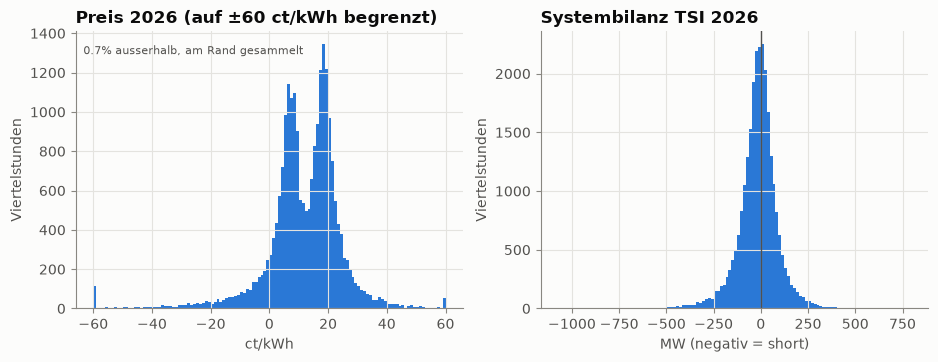

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(prices["aep_ct_kwh"].clip(-60, 60), bins=120, color=BLUE)
axes[0].set(title="Preis 2026 (auf ±60 ct/kWh begrenzt)", xlabel="ct/kWh", ylabel="Viertelstunden")
outside = (~prices["aep_ct_kwh"].between(-60, 60)).mean()
axes[0].text(0.02, 0.95, f"{outside:.1%} ausserhalb, am Rand gesammelt", transform=axes[0].transAxes, color=INK_2, fontsize=8, va="top")
axes[1].hist(cab["tsi_mw"], bins=120, color=BLUE)
axes[1].axvline(0, color=INK_2, linewidth=1)
axes[1].set(title="Systembilanz TSI 2026", xlabel="MW (negativ = short)", ylabel="Viertelstunden")
plt.show()

Der Preis hat einen schmalen Kern um 10 bis 20 ct/kWh und einen langen negativen Rand; die TSI ist eingipflig um 0. Kein Hinweis auf Platzhalterwerte (z.B. gehäuft 0 oder 999).

## 6. Zusammenhänge (beschreibend, dieselbe Viertelstunde)

In [10]:
joint = cab.merge(prices[["timestamp_utc", "aep_ct_kwh"]], on="timestamp_utc", how="inner")
print("price columns identical:", np.allclose(joint["price_ct_kwh"], joint["aep_ct_kwh"]), f"({len(joint)} quarter hours)")
corr = joint[["aep_ct_kwh"] + columns + ["frce_pos_mw", "frce_neg_mw"]].corr(method="spearman")
corr["aep_ct_kwh"].drop("aep_ct_kwh").round(2).sort_values()

price columns identical: True (23324 quarter hours)


tsi_mw           -0.77
frce_neg_mw      -0.05
frce_pos_mw       0.08
igcc_import_mw    0.34
igcc_export_mw    0.35
mfrr_sa_neg_mw    0.39
mfrr_sa_pos_mw    0.40
afrr_neg_mw       0.53
afrr_pos_mw       0.57
Name: aep_ct_kwh, dtype: float64

**F:** Wie hängt der Preis mit den Bilanzgrössen *derselben* Viertelstunde zusammen? **A:**
- `price_ct_kwh` der Regelzonenbilanz ist für Januar bis August zu 100 % identisch mit dem finalen Preis: dieselbe Grösse, nicht zweimal verwenden.
- Rangkorrelation Preis und TSI **−0.77** (wie in `docs/data.md`). Die Abrufe hängen erwartungsgemäss daran: Positive Regelenergie (`afrr_pos`, `mfrr_sa_pos`) geht mit hohen Preisen einher, negative mit tiefen.
- **Verbot als Merkmal:** All diese Grössen der Zielviertelstunde sind um 11:00 an D−1 unbekannt. Sie erklären den Mechanismus, sie sind keine Merkmale.

## 7. Zeitmuster: Abdeckung pro Monat

In [11]:
pd.DataFrame({
    "prices": prices.groupby(prices["timestamp_local"].dt.month).size(),
    "cab": cab.groupby(cab["timestamp_local"].dt.month).size(),
    "weather_days": weather.groupby(weather["delivery_day"].dt.month)["delivery_day"].nunique(),
})

,prices,cab,weather_days
1,2976.0,2976,31
2,2688.0,2688,28
3,2972.0,2972,31
4,2880.0,2880,30
5,2976.0,2976,31
6,2880.0,2880,30
7,2976.0,2976,31
8,2976.0,2976,31
9,NaN,2880,30
10,NaN,288,5


**F:** Gibt es Ausfälle oder Verdopplungen über die Zeit? **A:** Nein. Jeder Monat ist voll (Tage × 96 Viertelstunden, im März 4 weniger), Oktober ist erst angebrochen. Die Saison deckt nur Januar bis August (Preis) bzw. Anfang Oktober (TSI) ab; Herbst und Winter-Ende fehlen.

---
# Hypothesen

Für H1 bis H7 eine gemeinsame Tabelle pro Viertelstunde: TSI (bis 03.10.), Preis (bis 31.08.), PV-gewichtete Strahlungsprognose, Uhrzeit, Wochentag, Monat und Tagtyp.

In [12]:
weights = sites.set_index("site")["pv_share"]
radiation = eda.weather_to_quarter_hours(weather, weights, ["shortwave_radiation"])
holiday_share = eda.holiday_pv_share(holidays, pv_capacity)

qh = cab[["timestamp_utc", "timestamp_local", "tsi_mw"]].merge(prices[["timestamp_utc", "aep_ct_kwh"]], on="timestamp_utc", how="left")
qh = qh.merge(radiation, left_on="timestamp_utc", right_index=True, how="left")
local = qh["timestamp_local"]
qh = qh.assign(slot=eda.clock_slot(local), hour=local.dt.hour, weekday=local.dt.weekday, month=local.dt.month,
               date=local.dt.date, short=qh["tsi_mw"] < 0)
qh["day_type"] = eda.day_types(qh["date"], holiday_share)
print(qh.shape, "| radiation missing on:", sorted(set(qh.loc[qh["shortwave_radiation"].isna(), "date"])))

(26492, 12) | radiation missing on: [datetime.date(2026, 6, 24)]


Strahlung fehlt nur am 24.06.2026, alle 96 Viertelstunden (Archivlücke). Alle anderen Viertelstunden haben einen Wert.

## H1: Muster der Systembilanz nach Viertelstunde, Wochentag und Monat

**Hypothese:** Die Systembilanz hat ein wiederkehrendes Muster nach Viertelstunde des Tages, Wochentag und Monat.

Für H1 gilt der gemeinsame Zeitraum mit dem Preis (Januar bis August), damit TSI und Preis dieselben Tage zeigen. September und die drei Oktobertage der TSI bleiben hier weg.

In [13]:
h1 = qh[qh["aep_ct_kwh"].notna()].copy()  # Jan-Aug: the period with prices
print(f"{h1['date'].min()} .. {h1['date'].max()}, {len(h1)} quarter hours")

2026-01-01 .. 2026-08-31, 23324 quarter hours


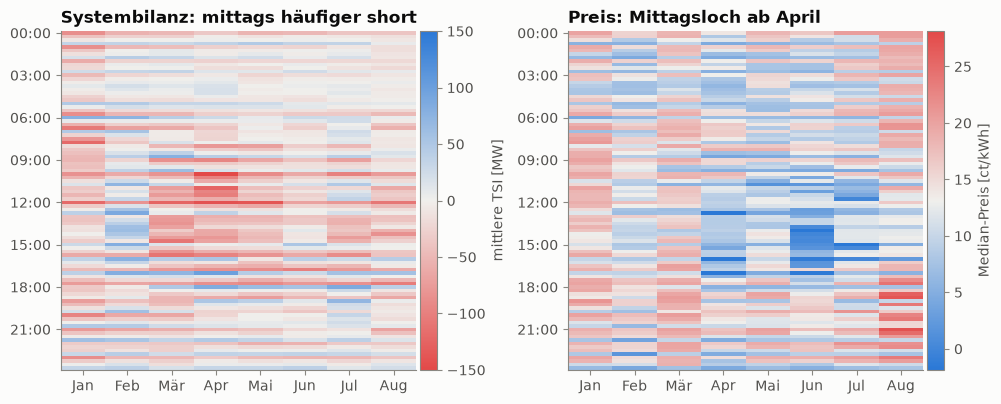

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
months = ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun", "Jul", "Aug"]
for ax, column, limit, label in [(axes[0], "tsi_mw", 150, "mittlere TSI [MW]"), (axes[1], "aep_ct_kwh", 15, "Median-Preis [ct/kWh]")]:
    agg = "mean" if column == "tsi_mw" else "median"
    grid = h1.pivot_table(index="slot", columns="month", values=column, aggfunc=agg)
    # TSI: negative (short) = red like high prices; price: low = blue, high = red
    cmap = DIVERGING.reversed() if column == "tsi_mw" else DIVERGING
    centre = 0.0 if column == "tsi_mw" else float(h1[column].median())
    im = ax.imshow(grid, aspect="auto", cmap=cmap, vmin=centre - limit, vmax=centre + limit, interpolation="nearest")
    ax.set_xticks(range(grid.shape[1]), [months[m - 1] for m in grid.columns])
    ax.set_yticks(range(0, 96, 12), [f"{h:02d}:00" for h in range(0, 24, 3)])
    ax.grid(False)
    fig.colorbar(im, ax=ax, pad=0.01).set_label(label, color=INK_2)
axes[0].set_title("Systembilanz: mittags häufiger short")
axes[1].set_title("Preis: Mittagsloch ab April")
save(fig, "eda_heatmap_tsi_price.png")
plt.show()

In [15]:
by_hour = h1.groupby("hour")["short"].mean()
print(f"share short overall {h1['short'].mean():.3f}")
print(f"by hour min/max: {by_hour.min():.3f} ({by_hour.idxmin()}h) / {by_hour.max():.3f} ({by_hour.idxmax()}h)")
print("by weekday", h1.groupby("weekday")["short"].mean().round(3).to_dict())
print("by month  ", h1.groupby("month")["short"].mean().round(3).to_dict())
tsi_hour = h1.groupby("hour")["tsi_mw"].mean()
print(f"mean TSI by hour: {tsi_hour.min():.0f} ({tsi_hour.idxmin()}h) .. {tsi_hour.max():.0f} ({tsi_hour.idxmax()}h), std of TSI {h1['tsi_mw'].std():.0f}")

share short overall 0.547
by hour min/max: 0.503 (4h) / 0.617 (13h)
by weekday {0: 0.554, 1: 0.521, 2: 0.527, 3: 0.538, 4: 0.522, 5: 0.579, 6: 0.585}
by month   {1: 0.586, 2: 0.501, 3: 0.58, 4: 0.563, 5: 0.544, 6: 0.516, 7: 0.509, 8: 0.57}
mean TSI by hour: -34 (11h) .. -4 (3h), std of TSI 109


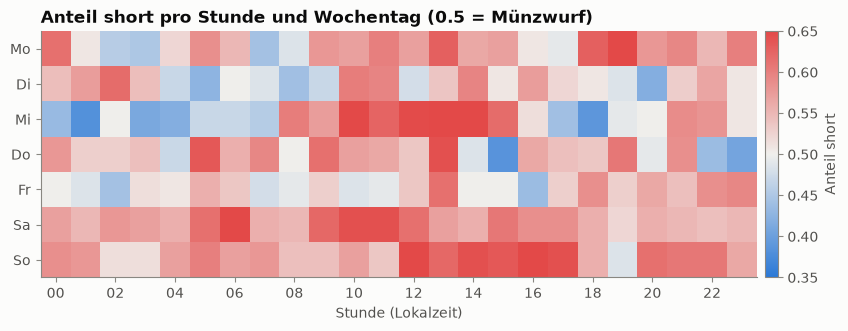

In [16]:
grid = h1.pivot_table(index="weekday", columns="hour", values="short", aggfunc="mean")
fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(grid, aspect="auto", cmap=DIVERGING, vmin=0.35, vmax=0.65, interpolation="nearest")
ax.set_yticks(range(7), ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"])
ax.set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
ax.set(xlabel="Stunde (Lokalzeit)", title="Anteil short pro Stunde und Wochentag (0.5 = Münzwurf)")
ax.grid(False)
fig.colorbar(im, ax=ax, pad=0.01).set_label("Anteil short", color=INK_2)
save(fig, "eda_short_share.png")
plt.show()

Die Heatmap links zeigt um die Mittagszeit in fast jedem Monat ein rotes Band. Ist die Mittagszeit (10 bis 14 Uhr) in jedem Monat negativer als der Rest des Tages?

In [17]:
midday = h1["hour"].between(10, 14)
per_month = pd.DataFrame({
    "tsi_midday": h1[midday].groupby("month")["tsi_mw"].mean(),
    "tsi_rest": h1[~midday].groupby("month")["tsi_mw"].mean(),
    "short_midday": h1[midday].groupby("month")["short"].mean(),
    "short_rest": h1[~midday].groupby("month")["short"].mean(),
})
print(f"all months: TSI midday {h1.loc[midday, 'tsi_mw'].mean():.1f} vs rest {h1.loc[~midday, 'tsi_mw'].mean():.1f} MW, "
      f"short {h1.loc[midday, 'short'].mean():.3f} vs {h1.loc[~midday, 'short'].mean():.3f}")
print("months with midday more negative:", int((per_month["tsi_midday"] < per_month["tsi_rest"]).sum()), "of", len(per_month))
per_month.round(2)

all months: TSI midday -32.4 vs rest -9.0 MW, short 0.586 vs 0.536
months with midday more negative: 7 of 8


,tsi_midday,tsi_rest,short_midday,short_rest
month,,,,
1,-28.84,-22.79,0.59,0.59
2,18.84,0.01,0.49,0.50
3,-53.76,-10.60,0.63,0.57
4,-65.56,-7.19,0.69,0.53
5,-41.77,-11.05,0.60,0.53
6,-19.03,-7.84,0.51,0.52
7,-25.91,-1.12,0.54,0.50
8,-38.99,-10.58,0.61,0.56


Die Heatmap zeigt ausserdem horizontale Streifen, das Tagesprofil in H7 ein Sägezahnmuster. Darum zusätzlich: Hängt es von der **Position der Viertelstunde in der Stunde** ab?

In [18]:
h1["minute"] = h1["timestamp_local"].dt.minute
within_hour = h1.groupby("minute").agg(short=("short", "mean"), tsi_median=("tsi_mw", "median"),
                                       price_median=("aep_ct_kwh", "median"), negative=("aep_ct_kwh", lambda s: (s < 0).mean()))
print(within_hour.round(3).to_string())
by_month_minute = h1.pivot_table(index="month", columns="minute", values="short", aggfunc="mean")
print("\nshare short at :00 above :45 in", int((by_month_minute[0] > by_month_minute[45]).sum()), "of", len(by_month_minute), "months")

        short  tsi_median  price_median  negative
minute                                           
0       0.584     -18.544         14.52     0.115
15      0.554      -9.715         13.59     0.096
30      0.548      -8.718         13.09     0.090
45      0.501      -0.267         11.09     0.122

share short at :00 above :45 in 8 of 8 months


**F (H1):** Hat die TSI ein Muster nach Uhrzeit, Wochentag und Monat? **A: Ja, aber schwach; ausser bei der Position in der Stunde.** (Januar bis August)
- **Mittags häufiger short:** Zwischen 10 und 14 Uhr liegt die mittlere TSI bei **−32 MW**, im Rest des Tages bei −9 MW; short-Anteil **59 %** gegenüber 54 %. Das gilt in **7 von 8 Monaten**, nur im Februar nicht. Am stärksten im April (−66 gegenüber −7 MW). Je Stunde reicht der short-Anteil von 50 % (04 Uhr) bis 62 % (13 Uhr).
- **Wochentag:** Samstag und Sonntag etwas häufiger short (58 % und 59 %) als Werktage (52 % bis 55 %).
- **Monat:** short-Anteil zwischen 50 % (Februar) und 59 % (Januar), ohne klare Saison.
- **Die Effekte sind klein gegen die Streuung:** Die Standardabweichung der TSI ist 109 MW, der Unterschied Mittag gegenüber Rest 23 MW. Das Muster verschiebt die Wahrscheinlichkeit für short um wenige Prozentpunkte, es bestimmt die Richtung nicht.
- **Deutlich ist die Position in der Stunde:** Die erste Viertelstunde (:00) ist zu **58 %** short, die letzte (:45) nur zu **50 %**; Median-TSI −19 gegenüber 0 MW, Median-Preis **14.5** gegenüber **11.1** ct/kWh. Das gilt in **allen 8 Monaten**. **Deutung (Vermutung):** Fahrpläne wechseln zur vollen Stunde in Stufen, Erzeugung und Verbrauch folgen gleitend.
- Der **Preis** hat ein deutliches Mittagsloch ab April (Heatmap rechts), obwohl die TSI mittags eher short ist (siehe H3).
- **Folge:** Uhrzeit, Wochentag und vor allem die Viertelstunde in der Stunde sind sinnvolle Kalendermerkmale, alle ohne Einschränkung erlaubt.

## H2: Wie stabil ist die Richtung über mehrere Tage?

**Hypothese:** Die Richtung (short/long) ist über mehrere Tage stabil: Zur gleichen Uhrzeit ist das System 2, 3 und 7 Tage später häufiger als zufällig in derselben Richtung.

In [19]:
matches = eda.direction_matches(cab, [1, 2, 3, 7])
p_short = (cab["tsi_mw"] < 0).mean()
chance = p_short**2 + (1 - p_short) ** 2
print(f"agreement by chance: {chance:.3f}")
matches.groupby("lag_days")["match"].agg(["mean", "size"])

agreement by chance: 0.505


,mean,size
lag_days,,
1,0.552326,26392
2,0.543619,26296
3,0.537481,26200
7,0.536063,25816


In [20]:
daily = qh.groupby("date").agg(tsi=("tsi_mw", "mean"), short=("short", "mean"))
pd.DataFrame({lag: {"daily mean TSI": daily["tsi"].autocorr(lag), "daily share short": daily["short"].autocorr(lag)}
              for lag in [1, 2, 3, 7]}).round(3)

,1,2,3,7
daily mean TSI,0.187,0.151,0.107,0.008
daily share short,0.237,0.109,0.047,0.008


hourly agreement for lags >= 2: 0.461 .. 0.584


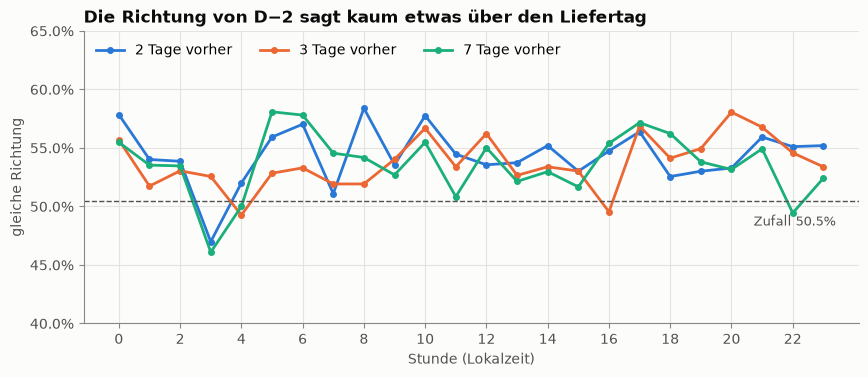

In [21]:
matches["hour"] = matches["slot"] // 4
per_hour = matches[matches["lag_days"] >= 2].groupby(["lag_days", "hour"])["match"].mean().unstack(0)
print(f"hourly agreement for lags >= 2: {per_hour.min().min():.3f} .. {per_hour.max().max():.3f}")
fig, ax = plt.subplots(figsize=(10, 3.8))
for colour, lag in zip(CATEGORICAL, per_hour.columns):
    ax.plot(per_hour.index, per_hour[lag], color=colour, marker="o", markersize=4, label=f"{lag} Tage vorher")
ax.axhline(chance, color=INK_2, linewidth=1, linestyle="--")
ax.text(23.4, chance - 0.012, f"Zufall {chance:.1%}", color=INK_2, ha="right", va="top", fontsize=9)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
ax.set(ylim=(0.4, 0.65), xticks=range(0, 24, 2), xlabel="Stunde (Lokalzeit)", ylabel="gleiche Richtung",
       title="Die Richtung von D−2 sagt kaum etwas über den Liefertag")
ax.legend(loc="upper left", ncols=3)
save(fig, "eda_direction_persistence.png")
plt.show()

**F (H2):** Ist das System zur gleichen Uhrzeit 2, 3 oder 7 Tage später in derselben Richtung? **A: Nur knapp öfter als per Zufall.**
- Zufallsniveau bei 55 % short: **50.5 %**. Gemessen: **54.4 %** nach 2 Tagen, **53.7 %** nach 3, **53.6 %** nach 7 Tagen (je rund 26'000 Vergleiche). Zum Vergleich der *nicht erlaubte* Abstand von 1 Tag: 55.2 %.
- Auf Tagesebene: Autokorrelation der mittleren TSI 0.19 (1 Tag), **0.15 (2 Tage)**, 0.11 (3), 0.01 (7).
- Keine Stunde sticht heraus (Spanne siehe Ausgabe über der Grafik).
- **Folge:** Die Vergangenheit bis D−2 trägt wenig zur Richtung am Liefertag bei. TSI-Merkmale aus der Vergangenheit sind erlaubt (über `known_at_issue()`), aber wenig erfolgversprechend. Am ehesten nützt ein Mass für das aktuelle *Niveau* (z.B. Mittel der TSI an D−2). Vorläufig, solange die Grenze D−2 nicht bestätigt ist.

## H3: Hängt die Strahlungsprognose mit der TSI zusammen, nicht nur mit dem Preis?

**Hypothese:** Die prognostizierte Strahlung hängt mit der TSI zusammen, nicht nur mit dem Preis (Weg „Sonne → Abweichung → Preis“).

In [22]:
day = qh[qh["shortwave_radiation"] > 50]  # daylight quarter hours


def spearman(frame: pd.DataFrame, a: str, b: str) -> float:
    return frame[[a, b]].corr(method="spearman").iloc[0, 1]


print(f"daylight quarter hours: {len(day)}")
print(f"radiation ~ TSI   {spearman(day, 'shortwave_radiation', 'tsi_mw'):+.3f}")
print(f"radiation ~ |TSI| {spearman(day.assign(a=day['tsi_mw'].abs()), 'shortwave_radiation', 'a'):+.3f}")
print(f"radiation ~ price {spearman(day, 'shortwave_radiation', 'aep_ct_kwh'):+.3f}")
for name, part in [("long", day[day["tsi_mw"] > 0]), ("short", day[day["tsi_mw"] < 0])]:
    print(f"radiation ~ price within {name:5s} {spearman(part, 'shortwave_radiation', 'aep_ct_kwh'):+.3f}  (n={len(part)})")
by_month = {m: spearman(g, "shortwave_radiation", "tsi_mw") for m, g in day.groupby("month")}
print("radiation ~ TSI by month:", {m: round(float(v), 2) for m, v in by_month.items()})

daylight quarter hours: 12752
radiation ~ TSI   -0.072
radiation ~ |TSI| +0.066
radiation ~ price -0.225
radiation ~ price within long  -0.582  (n=5623)
radiation ~ price within short -0.388  (n=7129)
radiation ~ TSI by month: {1: -0.01, 2: 0.0, 3: -0.08, 4: -0.14, 5: -0.12, 6: 0.07, 7: -0.1, 8: -0.13, 9: 0.0, 10: -0.18}


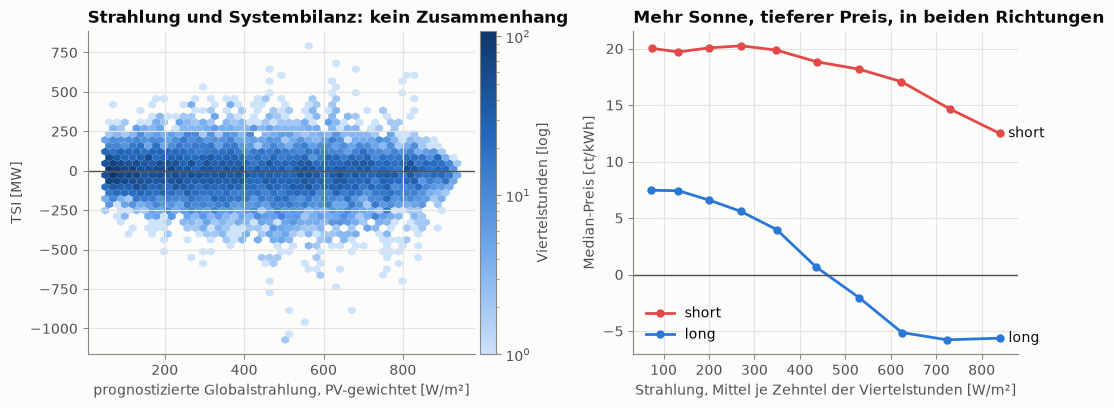

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.2, 1]})
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#6da7ec", "#256abf", "#0d366b"])
hb = axes[0].hexbin(day["shortwave_radiation"], day["tsi_mw"], gridsize=45, bins="log", mincnt=1, linewidths=0, cmap=cmap)
axes[0].axhline(0, color=INK_2, linewidth=1)
axes[0].set(xlabel="prognostizierte Globalstrahlung, PV-gewichtet [W/m²]", ylabel="TSI [MW]",
            title="Strahlung und Systembilanz: kein Zusammenhang")
fig.colorbar(hb, ax=axes[0], pad=0.01).set_label("Viertelstunden [log]", color=INK_2)

priced = day[day["aep_ct_kwh"].notna()]
bins = pd.qcut(priced["shortwave_radiation"], 10)
for colour, name, part in [(RED, "short", priced[priced["short"]]), (BLUE, "long", priced[~priced["short"]])]:
    med = part.groupby(bins.loc[part.index], observed=True).agg(rad=("shortwave_radiation", "mean"), price=("aep_ct_kwh", "median"))
    axes[1].plot(med["rad"], med["price"], color=colour, marker="o", markersize=5, label=name)
    axes[1].annotate(name, (med["rad"].iloc[-1], med["price"].iloc[-1]), xytext=(6, 0), textcoords="offset points", color=INK, va="center")
axes[1].axhline(0, color=INK_2, linewidth=1)
axes[1].set(xlabel="Strahlung, Mittel je Zehntel der Viertelstunden [W/m²]", ylabel="Median-Preis [ct/kWh]",
            title="Mehr Sonne, tieferer Preis, in beiden Richtungen")
axes[1].legend(loc="lower left")
save(fig, "eda_radiation_tsi.png")
plt.show()

**F (H3):** Läuft der Weg „Sonne → Abweichung → Preis“? **A: Nein, nicht über die TSI.**
- Strahlungsprognose und TSI derselben Viertelstunde (nur Tageslicht, über 12'000 Viertelstunden): Rangkorrelation **−0.07**; mit dem Betrag |TSI| **+0.07**. In keinem Monat über 0.18 im Betrag.
- Strahlung und Preis: **−0.23**. Innerhalb gleicher Richtung ist der Zusammenhang sogar stärker: **−0.58 bei long**, **−0.39 bei short**.
- **Deutung (Vermutung, nicht geprüft):** Die Sonne verschiebt nicht die Richtung, sondern das *Preisniveau* der abgerufenen Regelenergie, vermutlich über tiefe Spotpreise an sonnigen Mittagen. Das passt zum Mittagsloch in H1. Die *Abweichung* der tatsächlichen Strahlung von der Prognose wäre die fachlich richtige Grösse für die TSI, ist um 11:00 aber nicht bekannt.
- **Folge:** Die Strahlungsprognose (Lauf D−2 18 UTC, erlaubt) ist ein starker Kandidat **für das Preisniveau**, nicht für die Richtung.

## H4: Wann treten Extrempreise auf (unter −100 und über +50 ct/kWh)?

**Hypothese:** Extrempreise (unter −100 und über +50 ct/kWh) häufen sich nach Uhrzeit, Wochentag, Monat, an Feiertagen und bei grosser |TSI|.

In [24]:
events = eda.extreme_events(prices, low=-100, high=50)
extreme = qh[qh["aep_ct_kwh"].notna()].assign(
    kind=lambda d: np.select([d["aep_ct_kwh"] < -100, d["aep_ct_kwh"] > 50], ["low", "high"], "none"))
extreme = extreme[extreme["kind"] != "none"]
print(events.groupby("kind").agg(events=("start", "size"), quarter_hours=("quarter_hours", "sum"), longest=("quarter_hours", "max")))
print(f"share of quarter hours: {len(extreme) / qh['aep_ct_kwh'].notna().sum():.2%}")
for kind in ["low", "high"]:
    part = extreme[extreme["kind"] == kind]
    print(f"\n{kind}: {part['date'].nunique()} days, TSI median {part['tsi_mw'].median():.0f} MW, "
          f"range {part['tsi_mw'].min():.0f} .. {part['tsi_mw'].max():.0f}")
    print("  hours   ", part["hour"].value_counts().sort_index().to_dict())
    print("  weekday ", part["weekday"].value_counts().sort_index().to_dict())
    print("  months  ", part["month"].value_counts().sort_index().to_dict())
    print("  day type", part["day_type"].value_counts().to_dict())
events.sort_values("extreme").iloc[[0, 1, 2, -3, -2, -1]]

      events  quarter_hours  longest
kind                                
high      71            110        7
low       20             43        6
share of quarter hours: 0.66%

low: 17 days, TSI median 335 MW, range 48 .. 662
  hours    {10: 3, 11: 5, 12: 10, 13: 11, 14: 8, 15: 4, 16: 2}
  weekday  {0: 5, 1: 8, 2: 3, 4: 4, 5: 10, 6: 13}
  months   {2: 6, 3: 8, 4: 8, 5: 5, 6: 4, 7: 8, 8: 4}
  day type {'Werktag': 15, 'Sonntag': 13, 'Samstag': 10, 'Feiertag': 5}

high: 41 days, TSI median -312 MW, range -1072 .. -2
  hours    {1: 2, 2: 1, 3: 1, 4: 1, 6: 1, 7: 7, 8: 7, 9: 8, 10: 12, 11: 15, 12: 6, 13: 2, 14: 8, 15: 3, 16: 3, 17: 4, 18: 6, 19: 7, 20: 6, 21: 4, 22: 4, 23: 2}
  weekday  {0: 26, 1: 20, 2: 33, 3: 15, 4: 2, 5: 1, 6: 13}
  months   {1: 21, 2: 3, 3: 15, 4: 5, 5: 8, 6: 21, 7: 16, 8: 21}
  day type {'Werktag': 96, 'Sonntag': 13, 'Samstag': 1}


,kind,start,end,quarter_hours,extreme
22,low,2026-03-28 09:30:00+00:00,2026-03-28 10:45:00+00:00,6,-688.48
66,low,2026-07-19 10:00:00+00:00,2026-07-19 10:30:00+00:00,3,-429.10
39,low,2026-05-19 10:30:00+00:00,2026-05-19 11:15:00+00:00,4,-335.22
62,high,2026-07-01 08:45:00+00:00,2026-07-01 10:00:00+00:00,6,138.28
4,high,2026-01-08 08:15:00+00:00,2026-01-08 08:45:00+00:00,3,138.44
11,high,2026-02-18 07:00:00+00:00,2026-02-18 07:15:00+00:00,2,171.93


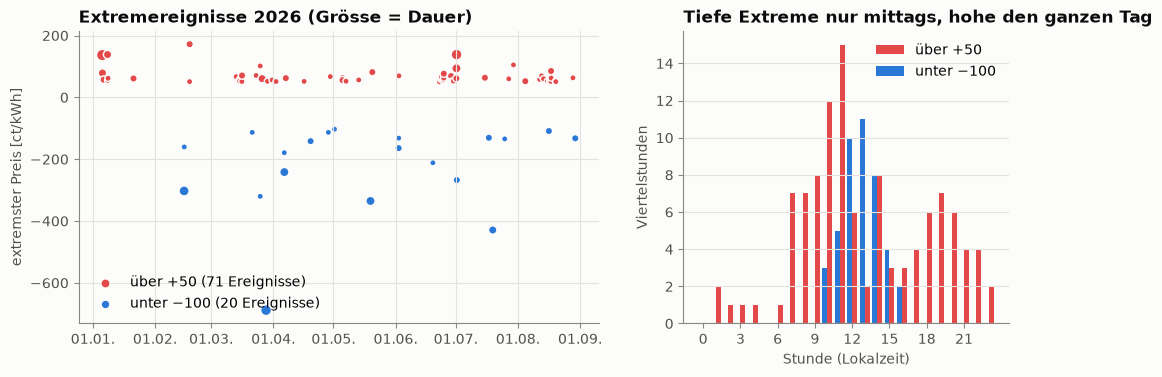

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1.6, 1]})
for colour, kind, label in [(RED, "high", "über +50"), (BLUE, "low", "unter −100")]:
    part = events[events["kind"] == kind]
    axes[0].scatter(part["start"].dt.tz_convert(TZ).dt.tz_localize(None), part["extreme"], s=12 + 8 * part["quarter_hours"],
                    color=colour, edgecolor=SURFACE, linewidth=1, label=f"{label} ({len(part)} Ereignisse)")
    counts = extreme[extreme["kind"] == kind]["hour"].value_counts().reindex(range(24), fill_value=0)
    axes[1].bar(counts.index + (0.2 if kind == "high" else -0.2), counts, width=0.4, color=colour, label=label)
axes[0].set(ylabel="extremster Preis [ct/kWh]", title="Extremereignisse 2026 (Grösse = Dauer)")
axes[0].legend(loc="lower left")
axes[0].xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%d.%m."))
axes[1].set(xlabel="Stunde (Lokalzeit)", ylabel="Viertelstunden", xticks=range(0, 24, 3), title="Tiefe Extreme nur mittags, hohe den ganzen Tag")
axes[1].legend(loc="upper right")
axes[1].grid(axis="x", visible=False)
save(fig, "eda_extremes.png")
plt.show()

**F (H4):** Wann treten Extrempreise auf? **A:**
- **Unter −100 ct/kWh:** 43 Viertelstunden in 20 Ereignissen an 17 Tagen, **nur zwischen 10 und 16 Uhr**, gehäuft am **Wochenende** (23 von 43 an Samstag oder Sonntag), Februar bis August. TSI immer **long** (+48 bis +662 MW, Median +335). Tiefster Wert −688 ct/kWh am 28.03.
- **Über +50 ct/kWh:** 110 Viertelstunden in 71 Ereignissen an 41 Tagen, verteilt über den Tag mit Schwerpunkt **07 bis 11 Uhr** und abends, fast nur **Montag bis Donnerstag** (Freitag und Samstag kaum, Sonntag 13). TSI immer **short** (−1072 bis −2 MW, Median −312).
- Ereignisse sind kurz: meist 1 bis 3 Viertelstunden, das längste 7.
- **Folge:** Extreme sind selten (0.7 % der Viertelstunden) und an Richtung, Tageszeit und Wochentag gebunden. Die Richtung selbst ist um 11:00 unbekannt (H2). Ein Modell sollte Extreme über breite obere und untere Quantile abbilden, nicht als Punktwert.

## H5: Unterscheidet sich `aep_ct_kwh` von Juli bis Dezember 2025 von 2026?

**Hypothese:** Der parallel publizierte Preis `aep_ct_kwh` von Juli bis Dezember 2025 ist ähnlich verteilt wie 2026. Dann wären 6 Monate mehr Trainingsdaten nutzbar.

In [26]:
local_all = prices_all["timestamp_local"]
p25 = prices_all[(local_all >= pd.Timestamp("2025-07-01", tz=TZ)) & (local_all < pd.Timestamp("2026-01-01", tz=TZ))]
p26 = prices
print("2025 aep equals long / short price:", np.isclose(p25["aep_ct_kwh"], p25["long_ct_kwh"]).mean(),
      np.isclose(p25["aep_ct_kwh"], p25["short_ct_kwh"]).mean())


def ks_statistic(a: np.ndarray, b: np.ndarray) -> float:
    a, b = np.sort(a), np.sort(b)
    grid = np.concatenate([a, b])
    return float(np.max(np.abs(np.searchsorted(a, grid, side="right") / len(a) - np.searchsorted(b, grid, side="right") / len(b))))


def describe(s: pd.Series) -> pd.Series:
    q = s.quantile([0.01, 0.1, 0.5, 0.9, 0.99]).rename(lambda x: f"P{int(round(x * 100))}")
    return pd.concat([q, pd.Series({"mean": s.mean(), "std": s.std(), "negative": (s < 0).mean(), "n": len(s)})])


summer25 = p25[p25["timestamp_local"].dt.month <= 8]["aep_ct_kwh"]
summer26 = p26[p26["timestamp_local"].dt.month >= 7]["aep_ct_kwh"]
print(f"KS distance all {ks_statistic(p25['aep_ct_kwh'].to_numpy(), p26['aep_ct_kwh'].to_numpy()):.3f}, "
      f"Jul-Aug vs Jul-Aug {ks_statistic(summer25.to_numpy(), summer26.to_numpy()):.3f}")
# One row per period, two comparisons: same season (Jul-Aug) and everything available.
pd.DataFrame({
    ("gleiche Saison", "2025 Jul-Aug"): describe(summer25), ("gleiche Saison", "2026 Jul-Aug"): describe(summer26),
    ("alles verfügbare", "2025 Jul-Dez"): describe(p25["aep_ct_kwh"]), ("alles verfügbare", "2026 Jan-Aug"): describe(p26["aep_ct_kwh"]),
}).T.round(2)

2025 aep equals long / short price: 0.0 0.0
KS distance all 0.183, Jul-Aug vs Jul-Aug 0.304


P1    P10    P50    P90    P99   mean  \
gleiche Saison   2025 Jul-Aug -44.44 -12.20   6.40  22.66  44.91   6.38   
                 2026 Jul-Aug -33.89  -1.20  12.92  27.10  45.40  12.75   
alles verfügbare 2025 Jul-Dez -40.63  -7.76  15.42  24.38  41.73   9.69   
                 2026 Jan-Aug -38.48  -0.56  13.13  23.97  42.07  11.56   

                                 std  negative        n  
gleiche Saison   2025 Jul-Aug  17.92      0.36   5952.0  
                 2026 Jul-Aug  16.59      0.11   5952.0  
alles verfügbare 2025 Jul-Dez  19.19      0.24  17668.0  
                 2026 Jan-Aug  16.42      0.11  23324.0

month     2025-07  2025-08  2025-09  2025-10  2025-11  2025-12  2026-01  2026-02  2026-03  2026-04  2026-05  2026-06  2026-07  2026-08
negative    0.398    0.316    0.312    0.184    0.146    0.101    0.045    0.058    0.073    0.166    0.130    0.152    0.133    0.089
median      3.260   13.015   12.265   17.820   18.915   16.305   16.620   12.365   17.040    9.880   11.825   11.145   11.755   16.915


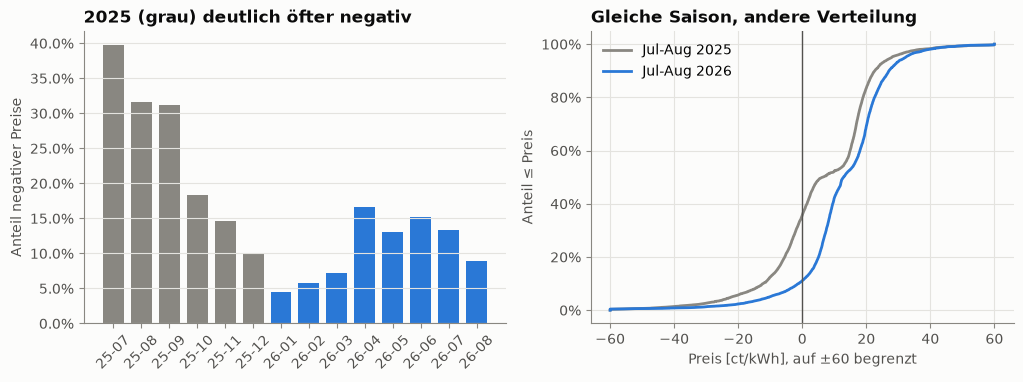

In [27]:
monthly = pd.concat([p25, p26]).assign(month=lambda d: d["timestamp_local"].dt.strftime("%Y-%m"))
monthly = monthly.groupby("month")["aep_ct_kwh"].agg(negative=lambda s: (s < 0).mean(), median="median")
print(monthly.round(3).T.to_string())
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
colours = [MUTED if m < "2026" else BLUE for m in monthly.index]
axes[0].bar(range(len(monthly)), monthly["negative"], color=colours, width=0.75)
axes[0].set_xticks(range(len(monthly)), [m[2:] for m in monthly.index], rotation=45)
axes[0].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
axes[0].set(ylabel="Anteil negativer Preise", title="2025 (grau) deutlich öfter negativ")
axes[0].grid(axis="x", visible=False)
for colour, label, s in [(MUTED, "Jul-Aug 2025", summer25), (BLUE, "Jul-Aug 2026", summer26)]:
    x = np.sort(s.clip(-60, 60))
    axes[1].plot(x, np.arange(1, len(x) + 1) / len(x), color=colour, label=label)
axes[1].axvline(0, color=INK_2, linewidth=1)
axes[1].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
axes[1].set(xlabel="Preis [ct/kWh], auf ±60 begrenzt", ylabel="Anteil ≤ Preis", title="Gleiche Saison, andere Verteilung")
axes[1].legend(loc="upper left")
save(fig, "eda_2025_vs_2026.png")
plt.show()

**F (H5):** Sind die parallel publizierten Preise von Juli bis Dezember 2025 wie 2026 verteilt? **A: Nein, deutlich verschieden.**
- `aep_ct_kwh` 2025 ist keiner der beiden damaligen Preise (0 % identisch mit long oder short), also tatsächlich eine Parallelrechnung.
- **Gleiche Saison verglichen** (Juli und August): 2025 waren **36 %** der Viertelstunden negativ, 2026 nur **11 %**. Median 6.4 gegenüber 12.9 ct/kWh, P10 −12.2 gegenüber −1.2. Kolmogorov-Smirnov-Abstand **0.30**.
- Über alle Monate: 24 % gegenüber 11 % negativ, KS-Abstand 0.18. Der Anteil negativer Preise fällt 2025 von 40 % (Juli) auf 10 % (Dezember), 2026 liegt er zwischen 5 % und 17 %.
- Ein p-Wert wird bewusst **nicht** angegeben: Benachbarte Viertelstunden sind stark abhängig, der übliche KS-Test wäre viel zu zuversichtlich.
- **Deutung (Vermutung):** Unter dem Zweipreissystem haben die Bilanzgruppen anders gehandelt; die Parallelrechnung legt den neuen Preis auf altes Verhalten. **Die Owner-Entscheidung „nur Daten ab 2026“ wird gestützt.** Die 2025er-Preise eignen sich höchstens für einen Robustheitstest, nicht als Trainingsdaten.

## H6: Feiertage und Brückentage

**Hypothese:** Preis und TSI unterscheiden sich an Feiertagen und Brückentagen von normalen Werktagen und Wochenenden.

In [28]:
with_price = qh[qh["aep_ct_kwh"].notna()]
special = with_price.drop_duplicates("date").query("day_type in @eda.HOLIDAY or day_type in @eda.BRIDGE_DAY")
print("holidays and bridge days with prices:", [(f"{d:%d.%m.}", t) for d, t in zip(special["date"], special["day_type"])])
with_price.groupby("day_type").agg(days=("date", "nunique"), price_median=("aep_ct_kwh", "median"),
                                   negative=("aep_ct_kwh", lambda s: (s < 0).mean()),
                                   tsi_mean=("tsi_mw", "mean"), short=("short", "mean")).reindex(eda.DAY_TYPES).round(3)

holidays and bridge days with prices: [('01.01.', 'Feiertag'), ('02.01.', 'Brückentag'), ('03.04.', 'Feiertag'), ('06.04.', 'Feiertag'), ('14.05.', 'Feiertag'), ('15.05.', 'Brückentag'), ('25.05.', 'Feiertag')]


,days,price_median,negative,tsi_mean,short
day_type,,,,,
Werktag,166,13.590,0.077,-11.673,0.532
Brückentag,2,13.935,0.161,-10.855,0.531
Samstag,35,12.895,0.157,-18.370,0.579
Sonntag,35,12.060,0.167,-20.859,0.585
Feiertag,5,8.440,0.258,-8.679,0.535


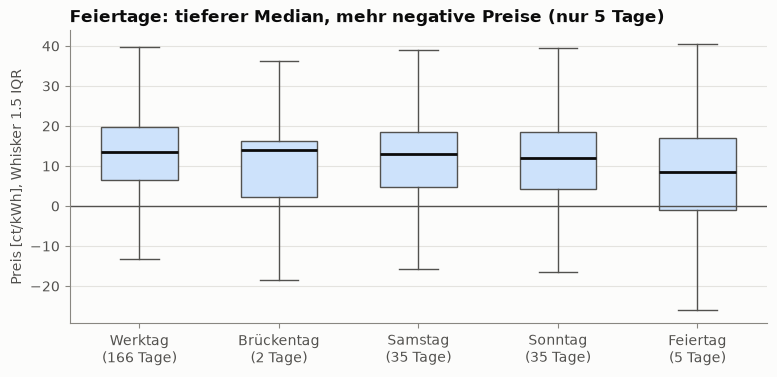

In [29]:
fig, ax = plt.subplots(figsize=(9, 3.8))
data = [with_price.loc[with_price["day_type"] == t, "aep_ct_kwh"] for t in eda.DAY_TYPES]
parts = ax.boxplot(data, showfliers=False, widths=0.55, patch_artist=True, medianprops={"color": INK, "linewidth": 2},
                   whiskerprops={"color": INK_2}, capprops={"color": INK_2})
for box in parts["boxes"]:
    box.set(facecolor="#cde2fb", edgecolor=INK_2)
days = with_price.groupby("day_type")["date"].nunique()
ax.set_xticks(range(1, 6), [f"{t}\n({days.get(t, 0)} Tage)" for t in eda.DAY_TYPES])
ax.axhline(0, color=INK_2, linewidth=1)
ax.set(ylabel="Preis [ct/kWh], Whisker 1.5 IQR", title="Feiertage: tieferer Median, mehr negative Preise (nur 5 Tage)")
ax.grid(axis="x", visible=False)
save(fig, "eda_day_types.png")
plt.show()

**F (H6):** Unterscheiden sich Feiertage und Brückentage? **A: Feiertage ja, mit sehr dünner Datenlage.**
- Als Feiertag zählt ein Montag bis Freitag, an dem Kantone mit mindestens **50 % der PV-Leistung** frei haben (`eda.day_types`). Bis 31.08. sind das nur **5 Tage** (01.01., Karfreitag, Ostermontag, Auffahrt, Pfingstmontag) und **2 Brückentage** (02.01., Freitag nach Auffahrt). Der 01.08. fiel auf einen Samstag.
- Feiertage: Median-Preis **8.4** ct/kWh, **26 %** negativ; Werktage 13.6 ct/kWh, **8 %** negativ; Wochenenden 12 bis 13 ct/kWh, 16 bis 17 % negativ. Feiertage verhalten sich also eher wie Sonntage, nur stärker (vier der fünf liegen im sonnigen Frühling).
- Die TSI unterscheidet sich kaum (short-Anteil 53 % bis 59 % über alle Tagtypen).
- Brückentage: 2 Tage, keine Aussage möglich.
- **Folge:** Ein Merkmal „Anteil der PV-Leistung mit Feiertag“ bzw. ein Tagtyp ist erlaubt und plausibel nützlich, der Effekt ist aber mit 5 Tagen statistisch nicht abgesichert und mit der Saison vermischt.

## H7: Tagesprofil des Preises mit P10, P50 und P90

**Hypothese:** Der Preis hat ein typisches Tagesprofil über die 96 Viertelstunden, und seine Streuung hängt von der Viertelstunde ab.

In [30]:
def clock(slot: int) -> str:
    return f"{slot // 4:02d}:{slot % 4 * 15:02d}"


profile = with_price.groupby("slot")["aep_ct_kwh"].quantile([0.1, 0.5, 0.9]).unstack()
width = profile[0.9] - profile[0.1]
print(f"median lowest {profile[0.5].min():.1f} at {clock(profile[0.5].idxmin())}, highest {profile[0.5].max():.1f} at {clock(profile[0.5].idxmax())}")
print(f"P10-P90 widest {width.max():.1f} at {clock(width.idxmax())}, narrowest {width.min():.1f} at {clock(width.idxmin())}")
summer = with_price[with_price["month"].between(4, 8)].groupby("slot")["aep_ct_kwh"].quantile([0.1, 0.5, 0.9]).unstack()
winter = with_price[with_price["month"] <= 3].groupby("slot")["aep_ct_kwh"].quantile([0.1, 0.5, 0.9]).unstack()
for name, frame in [("Jan-Mar", winter), ("Apr-Aug", summer)]:
    print(f"{name}: P10 lowest {frame[0.1].min():.1f} at {clock(frame[0.1].idxmin())}, median lowest {frame[0.5].min():.1f} at {clock(frame[0.5].idxmin())}")

median lowest 6.2 at 10:45, highest 19.0 at 21:00
P10-P90 widest 46.5 at 17:00, narrowest 15.2 at 03:15
Jan-Mar: P10 lowest -6.1 at 11:45, median lowest 6.3 at 23:45
Apr-Aug: P10 lowest -31.9 at 13:45, median lowest 1.2 at 16:00


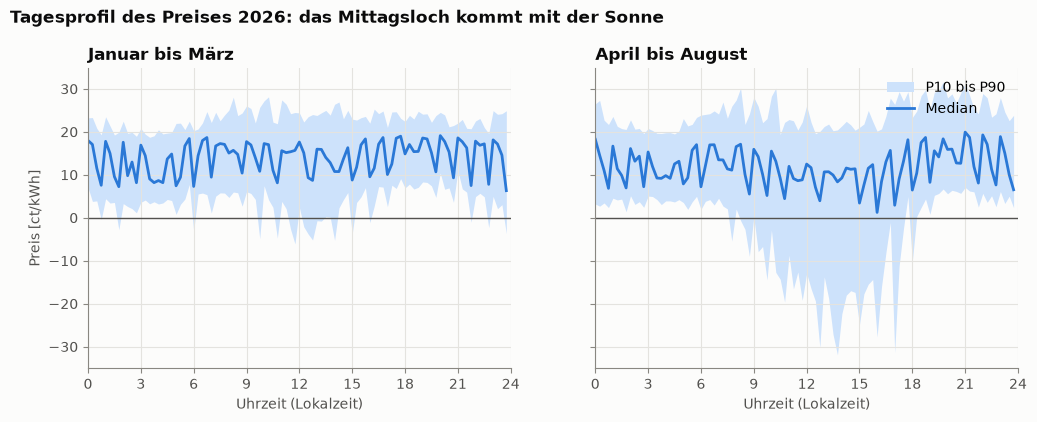

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), sharey=True)
for ax, frame, title in [(axes[0], winter, "Januar bis März"), (axes[1], summer, "April bis August")]:
    x = frame.index / 4
    ax.fill_between(x, frame[0.1], frame[0.9], color="#cde2fb", linewidth=0, label="P10 bis P90")
    ax.plot(x, frame[0.5], color=BLUE, label="Median")
    ax.axhline(0, color=INK_2, linewidth=1)
    ax.set(xlabel="Uhrzeit (Lokalzeit)", xticks=range(0, 25, 3), xlim=(0, 24), title=title)
axes[0].set_ylabel("Preis [ct/kWh]")
axes[1].legend(loc="upper right")
fig.suptitle("Tagesprofil des Preises 2026: das Mittagsloch kommt mit der Sonne", x=0.06, y=1.03, ha="left", fontweight="bold", color=INK)
save(fig, "eda_daily_profile.png")
plt.show()

**F (H7):** Wie verteilt sich der Preis über den Tag? **A:**
- Über 2026 liegt der Median um **10:45 am tiefsten (6.2 ct/kWh)** und um **21:00 am höchsten (19.0)**. Die Streuung P10 bis P90 ist am **Nachmittag am grössten (46.5 ct/kWh um 17:00)** und in der **Nacht am kleinsten (15.2 um 03:15)**, also rund dreimal schmaler.
- Das **Sägezahnmuster** innerhalb jeder Stunde ist der Effekt der Viertelstunden-Position aus H1.
- **Die Saison verändert das Profil stark:** Von April bis August fällt das P10 über Mittag bis **−31.9** ct/kWh (13:45) und der Median bis 1.2 (16:00); von Januar bis März erreicht das P10 nur **−6.1** (11:45). Ein einziges Profil für alle Monate wäre falsch.
- **Folge für Baseline und Unsicherheit:** Eine naive Baseline sollte Quantile pro Viertelstunde *und* Saison (bzw. Strahlungsprognose) nutzen. Die Breite der Bänder muss von der Uhrzeit abhängen.

## H8: Warum ist die erste Viertelstunde einer Stunde öfter short?

H1 hat gezeigt: Um :00 ist das System zu 58 % short, um :45 nur zu 50 %. Dieser Abschnitt sucht die Ursache.

**Hypothese:** Fahrpläne und viele Kraftwerke wechseln zur vollen Stunde in Stufen, Verbrauch und PV-Erzeugung ändern sich dagegen gleitend. Darum kippt die TSI *innerhalb* jeder Stunde, und die Richtung folgt der Steigung der Residuallast (Verbrauch minus PV):
- Residuallast **steigt** (z.B. morgens vor Sonnenaufgang, abends bei Sonnenuntergang): Zu Beginn der Stunde ist noch zu viel Erzeugung da (:00 long), am Ende zu wenig (:45 short).
- Residuallast **fällt** (z.B. vormittags mit steigender PV, spätabends): umgekehrt, :00 short und :45 long.

**Quellen für den Mechanismus:**
- EURELECTRIC und ENTSO-E, „Deterministic frequency deviations: root causes and proposals for potential solutions“ (Dezember 2011): Kraftwerke ändern ihre Einspeisung zur vollen Stunde fast stufenweise, der Verbrauch langsamer; am stärksten um 6, 7, 8 und 21, 22, 23 Uhr.
- Swissgrid, Allgemeine Bilanzgruppenvorschriften v3.2, Ziffer 7.2: Fahrplanwechsel werden als Rampe von 5 Minuten vor bis 5 Minuten nach dem Wechsel abgerechnet.

In [32]:
trend = eda.within_hour_trend(h1)
by_hour = trend.groupby("hour")[["q00", "q15", "q30", "q45", "trend"]].mean()
short_by = h1.pivot_table(index="hour", columns="minute", values="short", aggfunc="mean")
by_hour["short_00"], by_hour["short_45"] = short_by[0], short_by[45]
print(f"{len(trend)} complete hours; mean TSI per quarter hour of the clock hour [MW] and share short at :00 and :45")
by_hour.round(2)

5831 complete hours; mean TSI per quarter hour of the clock hour [MW] and share short at :00 and :45


,q00,q15,q30,q45,trend,short_00,short_45
hour,,,,,,,
0,-49.93,-16.56,-1.73,31.43,81.36,0.80,0.30
1,-34.23,-5.96,-0.77,17.92,52.15,0.69,0.36
2,-27.44,-2.69,-10.19,19.45,46.89,0.67,0.35
3,-19.84,-5.36,1.79,8.08,27.92,0.63,0.45
4,2.72,2.41,-7.21,-13.28,-16.00,0.46,0.57
5,26.20,9.22,-18.20,-44.84,-71.03,0.35,0.79
6,34.69,6.71,-25.94,-43.26,-77.95,0.32,0.70
7,9.41,-3.84,-16.64,-15.35,-24.76,0.43,0.53
8,-38.82,-16.79,3.75,26.17,64.99,0.63,0.36


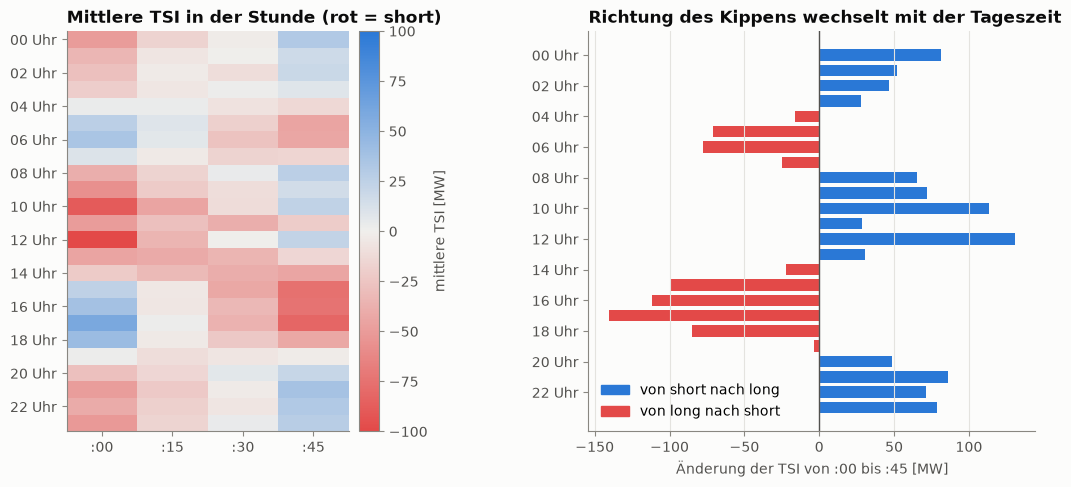

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), gridspec_kw={"width_ratios": [1, 1.3], "wspace": 0.45})
im = axes[0].imshow(by_hour[["q00", "q15", "q30", "q45"]], aspect="auto", cmap=DIVERGING.reversed(), vmin=-100, vmax=100,
                    interpolation="nearest")
axes[0].set_xticks(range(4), [":00", ":15", ":30", ":45"])
axes[0].set_yticks(range(0, 24, 2), [f"{h:02d} Uhr" for h in range(0, 24, 2)])
axes[0].grid(False)
axes[0].set_title("Mittlere TSI in der Stunde (rot = short)")
fig.colorbar(im, ax=axes[0], pad=0.03).set_label("mittlere TSI [MW]", color=INK_2)
colours = [BLUE if v > 0 else RED for v in by_hour["trend"]]
axes[1].barh(by_hour.index, by_hour["trend"], color=colours, height=0.75)
axes[1].axvline(0, color=INK_2, linewidth=1)
axes[1].invert_yaxis()
axes[1].set_yticks(range(0, 24, 2), [f"{h:02d} Uhr" for h in range(0, 24, 2)])
axes[1].set(xlabel="Änderung der TSI von :00 bis :45 [MW]", title="Richtung des Kippens wechselt mit der Tageszeit")
axes[1].legend(handles=[matplotlib.patches.Patch(color=BLUE, label="von short nach long"),
                        matplotlib.patches.Patch(color=RED, label="von long nach short")], loc="lower left")
axes[1].grid(axis="y", visible=False)
save(fig, "eda_within_hour.png")
plt.show()

Welche Regelenergie gleicht das Kippen aus? Mittel der Netto-Abrufe je Position in der Stunde (positiv = Hochregeln, also Ausgleich von short).

In [34]:
flows = cab[cab["timestamp_local"] < pd.Timestamp("2026-09-01", tz=TZ)].dropna()
flows = pd.DataFrame({
    "minute": flows["timestamp_local"].dt.minute,
    "tsi_mw": flows["tsi_mw"],
    "afrr_net": flows["afrr_pos_mw"] + flows["afrr_neg_mw"],
    "mfrr_net": flows["mfrr_sa_pos_mw"] + flows["mfrr_sa_neg_mw"],
    "igcc_net": flows["igcc_import_mw"] + flows["igcc_export_mw"],
    "frce_net": flows["frce_pos_mw"] + flows["frce_neg_mw"],
})
flows.groupby("minute").mean().round(1)

,tsi_mw,afrr_net,mfrr_net,igcc_net,frce_net
minute,,,,,
0,-19.5,3.8,17.7,-4.5,2.5
15,-13.6,5.5,12.2,-2.1,-2.0
30,-14.6,4.1,10.7,-1.8,1.6
45,-7.8,2.9,3.1,4.1,-2.3


Wenn die Steigung der Residuallast das Kippen steuert, muss die **Steigung der Strahlungsprognose** (Lauf D−2 18 UTC, um 11:00 bekannt) damit zusammenhängen: steigende Sonne heisst fallende Residuallast, also Kippen von short nach long (positive Änderung).

In [35]:
hourly_rad = h1.groupby(["date", "hour"])["shortwave_radiation"].mean()
# change of the forecast radiation across the hour: next hour minus previous hour of the same day
rad_slope = (hourly_rad.groupby(level="date").shift(-1) - hourly_rad.groupby(level="date").shift(1)).rename("rad_slope")
joined = trend.set_index(["date", "hour"])[["trend"]].join(rad_slope, how="inner").dropna()
sunny = joined[joined["rad_slope"] != 0]  # hours with changing sun only
print(f"hours with changing radiation: {len(sunny)}, Spearman(trend, radiation slope) = "
      f"{sunny[['trend', 'rad_slope']].corr(method='spearman').iloc[0, 1]:.3f}")
bins = pd.qcut(sunny["rad_slope"], 5)
by_slope = sunny.groupby(bins, observed=True).agg(rad_slope=("rad_slope", "mean"), trend_mean=("trend", "mean"),
                                                  trend_median=("trend", "median"), hours=("trend", "size"))
by_slope.round(1)

hours with changing radiation: 3880, Spearman(trend, radiation slope) = 0.473


,rad_slope,trend_mean,trend_median,hours
rad_slope,,,,
"(-392.772, -190.995]",-263.9,-122.2,-115.9,776
"(-190.995, -45.655]",-116.0,-25.7,-14.5,776
"(-45.655, 37.661]",-1.7,12.3,15.5,776
"(37.661, 188.835]",109.5,20.3,8.6,776
"(188.835, 435.709]",272.2,85.8,82.4,776


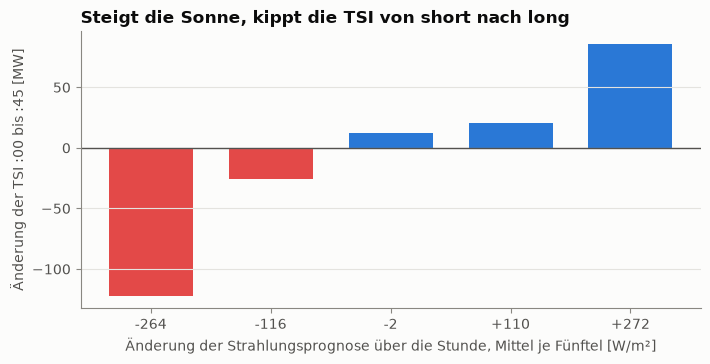

In [36]:
fig, ax = plt.subplots(figsize=(8, 3.6))
colours = [BLUE if v > 0 else RED for v in by_slope["trend_mean"]]
ax.bar(range(len(by_slope)), by_slope["trend_mean"], color=colours, width=0.7)
ax.axhline(0, color=INK_2, linewidth=1)
labels = [f"{v:+.0f}" for v in by_slope["rad_slope"]]
ax.set_xticks(range(len(by_slope)), labels)
ax.set(xlabel="Änderung der Strahlungsprognose über die Stunde, Mittel je Fünftel [W/m²]",
       ylabel="Änderung der TSI :00 bis :45 [MW]", title="Steigt die Sonne, kippt die TSI von short nach long")
ax.grid(axis="x", visible=False)
save(fig, "eda_within_hour_radiation.png")
plt.show()

Verschieben sich die Kipp-Stunden mit Sonnenauf- und -untergang über die Monate?

In [37]:
month_hour = trend.assign(month=pd.to_datetime(trend["date"]).dt.month).pivot_table(index="month", columns="hour", values="trend", aggfunc="mean")
month_hour[[5, 6, 7, 8, 9, 16, 17, 18, 19, 20, 21]].round(0)

hour,5,6,7,8,9,16,17,18,19,20,21
month,,,,,,,,,,,
1,-135.0,-181.0,-167.0,-31.0,18.0,-84.0,-113.0,28.0,94.0,142.0,136.0
2,-97.0,-143.0,-90.0,46.0,60.0,-128.0,-146.0,14.0,101.0,110.0,119.0
3,-84.0,-103.0,21.0,127.0,149.0,-120.0,-141.0,-99.0,70.0,90.0,93.0
4,-61.0,-64.0,24.0,121.0,112.0,-138.0,-185.0,-145.0,-75.0,37.0,96.0
5,-52.0,-3.0,17.0,101.0,69.0,-80.0,-135.0,-137.0,-64.0,9.0,75.0
6,-40.0,-57.0,6.0,48.0,51.0,-140.0,-106.0,-106.0,-49.0,5.0,37.0
7,-44.0,-17.0,-12.0,89.0,91.0,-105.0,-140.0,-123.0,-90.0,-16.0,50.0
8,-56.0,-61.0,-2.0,19.0,27.0,-104.0,-160.0,-103.0,-10.0,18.0,83.0


Und folgt der Preis dem Kippen? Median-Preis um :00 und :45, getrennt nach Stunden, in denen die TSI im Mittel von short nach long kippt und umgekehrt.

In [38]:
rising = by_hour.index[by_hour["trend"] > 0]  # short at :00, long at :45
prices_hour = h1[h1["minute"].isin([0, 45])].assign(kind=lambda d: np.where(d["hour"].isin(rising), "short nach long", "long nach short"))
prices_hour.pivot_table(index="kind", columns="minute", values="aep_ct_kwh", aggfunc="median").round(1)

minute,0,45
kind,,
long nach short,8.8,16.5
short nach long,16.9,8.0


**F (H8):** Warum ist die erste Viertelstunde öfter short? **A: Weil die TSI in jeder Stunde kippt, und zwar in den meisten Stunden von short nach long.** Die Hypothese ist mit den Daten vereinbar; der Mechanismus selbst ist nicht direkt gemessen, weil Fahrpläne und Verbrauch nicht in unseren Daten sind.
- **Das Kippen ist gross und regelmässig:** Um 17 Uhr ist die TSI um :00 im Mittel +59 MW (zu 30 % short), um :45 −82 MW (zu 79 % short). Um 12 Uhr ist es umgekehrt: −108 MW um :00, +23 MW um :45. Die vier Viertelstunden liegen meist fast auf einer Geraden, wie bei einer Stufe im Fahrplan gegen eine gleitende Änderung zu erwarten.
- **Die Richtung wechselt mit der Tageszeit**, genau wie die Residuallast:
  - **von long nach short** (Residuallast steigt) um 04 bis 07 Uhr (Morgenrampe vor und um Sonnenaufgang) und 14 bis 18 Uhr (PV nimmt ab);
  - **von short nach long** (Residuallast fällt) um 08 bis 13 Uhr (PV nimmt zu) und 20 bis 03 Uhr (Verbrauch sinkt am Abend und in der Nacht).
- **Warum im Mittel :00 öfter short ist:** 15 der 24 Stunden kippen von short nach long. Der Mittelwert aus H1 (58 % gegenüber 50 %) ist also eine Mischung aus zwei entgegengesetzten Mustern und unterschätzt den Effekt stark: Je nach Stunde liegt der short-Anteil um :00 zwischen 30 % und 80 %.
- **Die Sonne steuert es mit:** Die Änderung der Strahlungsprognose über die Stunde hängt mit dem Kippen zusammen (Rangkorrelation **0.47**, 3'880 Stunden). Steigt die Strahlung stark (+272 W/m²), kippt die TSI im Mittel um **+86 MW** nach long; fällt sie stark (−264 W/m²), um **−122 MW** nach short.
- **Die Kipp-Stunden wandern mit Sonnenauf- und -untergang:** Um 07 Uhr kippt die TSI im Januar nach short (−167 MW, Morgenrampe im Dunkeln), ab März nach long (PV steigt schon). Um 19 Uhr kippt sie im Januar nach long (+94 MW), von April bis Juli nach short (PV geht zurück).
- **Ausgeglichen wird es vor allem mit manueller Regelenergie:** Die Netto-Abrufe von mFRR sind um :00 mit +18 MW am höchsten und um :45 mit +3 MW am tiefsten.
- **Der Preis folgt:** In Stunden, die von short nach long kippen, ist der Median-Preis um :00 **16.9** und um :45 **8.0** ct/kWh. In Stunden, die von long nach short kippen, ist es umgekehrt (8.8 und 16.5).
- **Folge für das Modell:** Die Kombination aus **Viertelstunde in der Stunde × Uhrzeit** und die **Steigung der Strahlungsprognose** sind starke, um 11:00 bekannte Merkmale. Für die Stunden ohne Sonne (Abend, Nacht, Morgen) würde die Steigung der Lastprognose dasselbe leisten; dafür bräuchte es die ENTSO-E-Lastprognose.

---
## Fazit

| # | Antwort in einem Satz |
|---|---|
| H1 | Teilweise: mittags (10 bis 14 Uhr) in 7 von 8 Monaten häufiger short (59 % gegenüber 54 %), deutlich nach Position in der Stunde (:00 zu 58 % short, :45 zu 50 %); Wochentag und Monat schwach. Der Preis hat ein Mittagsloch ab April. |
| H2 | Die Richtung von D−2 stimmt nur in 54 % mit dem Liefertag überein, Zufall wäre 50.5 %. |
| H3 | Die Strahlungsprognose hängt nicht mit der TSI zusammen (−0.07), aber mit dem Preisniveau (−0.58 bei long). |
| H4 | Tiefe Extreme nur mittags bei long, oft am Wochenende; hohe Extreme bei short, an Werktagen, morgens und abends. |
| H5 | 2025 und 2026 sind klar verschieden (Jul-Aug: 36 % gegenüber 11 % negativ); nur 2026 verwenden. |
| H6 | Feiertage: tieferer Preis und mehr negative Preise, aber nur 5 Tage Belege. |
| H7 | Streuung am Nachmittag am grössten; das Profil hängt stark von der Saison ab. |
| H8 | Die TSI kippt innerhalb jeder Stunde, die Richtung folgt der Residuallast (z.B. 17 Uhr: :00 zu 30 %, :45 zu 79 % short). Die Steigung der Strahlungsprognose erklärt einen Teil (0.47). |

**Grenzen:** Preise für nur 8 Monate, Herbst und Winter-Ende fehlen. Alle Swissgrid-Werte sind final, nicht provisorisch; die Grenze D−2 ist bis ca. 18.10.2026 eine Annahme. Deutungen in H3 und H5 sind Vermutungen.

Merkmals-Kandidaten, Fragen an den Owner und nächste Schritte: [`docs/eda.md`](../docs/eda.md).